[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01/blob/main/defect_detection.ipynb)

TODO: fix the button

# PBF Defect Detection

This notebook covers data loading, training, validation, and inference for detecting defects in Powder Bed Fusion images using a fine-tuned CNN.

## Clone GithHub repo

In [ ]:
!rm -rf mla_project/

In [1]:
import os

if not os.path.exists("/content/mla-prj-23-project-am04_group-am01") and not os.path.exists("/content/mla_project"):
  # DON'T SHARE THE PERSONAL ACCESS TOKEN

  # change the name of the branch here as needed
  !git clone -b giacomo https://***REMOVED-GITHUB-TOKEN***@github.com/MLinApp-polito/mla-prj-23-project-am04_group-am01.git

  # Rename folder for simplicity
  !mv /content/mla-prj-23-project-am04_group-am01 /content/mla_project

!cd /content/mla_project && git pull

Cloning into 'mla-prj-23-project-am04_group-am01'...
remote: Enumerating objects: 1484, done.
remote: Counting objects: 100% (217/217), done.
remote: Compressing objects: 100% (152/152), done.
remote: Total 1484 (delta 93), reused 166 (delta 57), pack-reused 1267 (from 1)
Receiving objects: 100% (1484/1484), 1.58 GiB | 15.75 MiB/s, done.
Resolving deltas: 100% (761/761), done.
Updating files: 100% (152/152), done.
Already up to date.


## Install Dependencies

In [2]:
!pip install torch torchvision matplotlib tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 102.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitl

## Imports

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt

## Dataset mean and std

In [ ]:
!python /content/mla_project/src/data_loader.py --data-dir /content/mla_project/images --compute-stats

Dataset mean (grayscale): 0.5830
Dataset std (grayscale): 0.2075


# Augmentation

## Augmentation with SinGAN

In [4]:
!rm -rf /content/TrainedModels/
!python /content/mla_project/SinGAN/main_train.py --input_dir '/content/mla_project/images/Defects/' --input_name 'Image0.jpg' --mode 'train'

Random Seed:  9835
Reading image from /content/mla_project/images/Defects/Image0.jpg
Image shape before np2torch:  (1024, 1280)
Image shape after np2torch:  torch.Size([1, 1, 1024, 1280])
Reading image from /content/mla_project/images/Defects/Image0.jpg
Image shape before np2torch:  (1024, 1280)
Image shape after np2torch:  torch.Size([1, 1, 1024, 1280])
Image size: 410 x 512
Number of scales: 18
stop_scale: 18
Image size at scale 0: 11x13
R1 penalty is not used
scale 0:[0/300] - errD: -1.6414, errG: 1.0383
scale 0:[10/300] - errD: -6.9810, errG: 3.4297
scale 0:[20/300] - errD: -8.4743, errG: 4.7377
scale 0:[30/300] - errD: -3.4767, errG: -1.5676
scale 0:[40/300] - errD: -15.4981, errG: 7.8136
scale 0:[50/300] - errD: -8.6921, errG: 11.1563
scale 0:[60/300] - errD: -19.2728, errG: 13.7177
scale 0:[70/300] - errD: -15.5339, errG: 9.0771
scale 0:[80/300] - errD: -24.5922, errG: 17.1541
scale 0:[90/300] - errD: -12.3616, errG: 1.4317
scale 0:[100/300] - errD: -21.6782, errG: 9.6558
scale 

In [9]:
!zip random_samples.zip /content/Output/RandomSamples/
!zip trained_models.zip /content/TrainedModels/

updating: content/Output/RandomSamples/ (stored 0%)
  adding: content/TrainedModels/ (stored 0%)


## Training

### Define paths and parameters

In [ ]:
data_dir = '/content/mla_project/images'
train_dir = os.path.join(data_dir, 'train')
val_dir   = os.path.join(data_dir, 'val')

# Training params
batch_size = 1
epochs = 10
learning_rate = 1e-3
backbone = 'resnet50'
device = 'cuda' if __import__('torch').cuda.is_available() else 'cpu'
print(f"Using device: {device}")

Using device: cuda


### Test Loading data

In [ ]:
# !python /content/mla_project/src/data_loader.py \
#     --data-dir "{data_dir}" \
#     --batch-size {batch_size} \
#     --val-split 0.2 \
#     --num-workers 2

Number of training batches: 59
Number of validation batches: 15


### Launch training

In [ ]:
# Execute train script directly

!python /content/mla_project/src/train.py \
    --data-dir "{data_dir}" \
    --batch-size {batch_size} \
    --epochs {epochs} \
    --lr {learning_rate} \
    --backbone {backbone} \
    --num-workers 2 \
    --k-folds 5

Using device: cuda

===== Fold 1 =====
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)

-- train --
Predictions:  [1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0]
Labels:  [1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0]

-- val --
Predictions:  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Labels:  [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]
[Fold 1] Epoch 1/10 | Train Loss: 0.5343

### Plot Training & Validation Curves

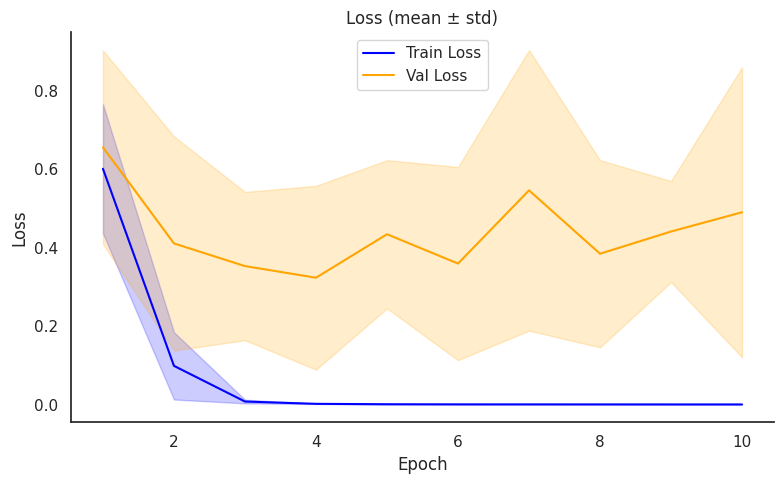

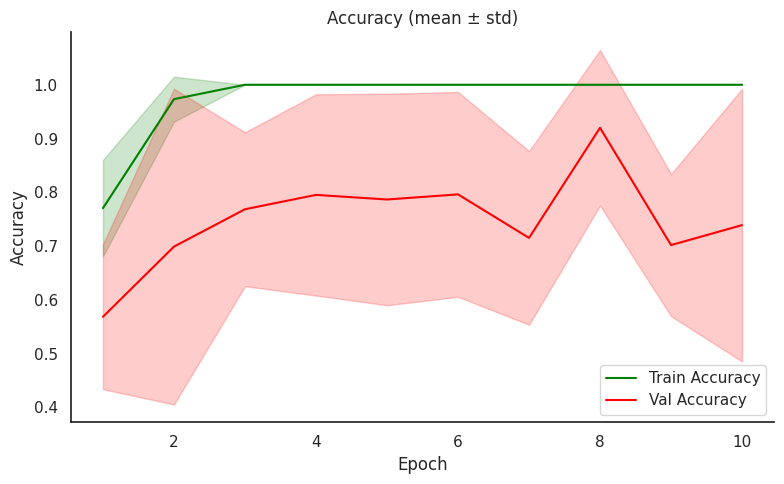

In [ ]:
# plot for cross-validation
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Read logs
logs = pd.read_csv('/content/kfold_logs.csv')

# Group for epoch and get mean and std
grouped = logs.groupby('epoch').agg({
    'train_loss': ['mean', 'std'],
    'val_loss': ['mean', 'std'],
    'train_acc': ['mean', 'std'],
    'val_acc': ['mean', 'std']
}).reset_index()

# Rename columns
grouped.columns = ['epoch',
                   'train_loss_mean', 'train_loss_std',
                   'val_loss_mean', 'val_loss_std',
                   'train_acc_mean', 'train_acc_std',
                   'val_acc_mean', 'val_acc_std']

# Set style
sns.set(style="white", context="notebook")

# LOSS
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_loss_mean'], label='Train Loss', color='blue')
plt.fill_between(grouped['epoch'],
                 grouped['train_loss_mean'] - grouped['train_loss_std'],
                 grouped['train_loss_mean'] + grouped['train_loss_std'],
                 color='blue', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_loss_mean'], label='Val Loss', color='orange')
plt.fill_between(grouped['epoch'],
                 grouped['val_loss_mean'] - grouped['val_loss_std'],
                 grouped['val_loss_mean'] + grouped['val_loss_std'],
                 color='orange', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

# ACCURACY
plt.figure(figsize=(8, 5))
plt.plot(grouped['epoch'], grouped['train_acc_mean'], label='Train Accuracy', color='green')
plt.fill_between(grouped['epoch'],
                 grouped['train_acc_mean'] - grouped['train_acc_std'],
                 grouped['train_acc_mean'] + grouped['train_acc_std'],
                 color='green', alpha=0.2)

plt.plot(grouped['epoch'], grouped['val_acc_mean'], label='Val Accuracy', color='red')
plt.fill_between(grouped['epoch'],
                 grouped['val_acc_mean'] - grouped['val_acc_std'],
                 grouped['val_acc_mean'] + grouped['val_acc_std'],
                 color='red', alpha=0.2)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy (mean ± std)')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()
